In [1]:
import pickle
import numpy as np
from pathlib import Path
from scipy.signal import butter, sosfiltfilt, find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# ПАРАМЕТРЫ
# ============================================================================

SUBJECTS = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 
            'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']

DATA_DIR = Path('model/wesad')
WINDOW_SIZE_SEC = 30
FS = 700  # 700 Hz

EMOTION_NAMES = {
    1: '😐 Baseline (спокойствие)',
    2: '😰 Stress (стресс)',
    3: '😂 Amusement (веселье)',
    4: '🧘 Meditation (медитация)'
}

# ============================================================================
# ФУНКЦИЯ 1: Извлечение HRV признаков
# ============================================================================

def extract_hrv_features(ecg_segment, fs=700):
    """
    Извлекает 4 HRV признака из куска ECG
    
    Вход:
        ecg_segment - 1D массив ECG
        fs - частота дискретизации (700 Hz)
    
    Выход:
        [SDNN, RMSSD, pNN50, Mean_HR] или None если ошибка
    """
    
    if len(ecg_segment) < int(fs * 5):  # минимум 5 сек
        return None
    
    # Фильтруем 5-15 Hz
    sos = butter(2, [5, 15], btype='band', fs=fs, output='sos')
    ecg_band = sosfiltfilt(sos, ecg_segment)
    
    # Возводим в квадрат
    ecg_squared = ecg_band ** 2
    
    # Интегрируем (150 ms)
    window_size = int(0.15 * fs)
    ecg_integrated = np.convolve(ecg_squared, 
                                 np.ones(window_size)/window_size, 
                                 mode='same')
    
    # Ищем пики
    threshold = np.mean(ecg_integrated) + 0.5 * np.std(ecg_integrated)
    r_peaks, _ = find_peaks(ecg_integrated, 
                            height=threshold, 
                            distance=int(0.4 * fs))
    
    if len(r_peaks) < 4:
        return None
    
    # Вычисляем RR интервалы
    rr_samples = np.diff(r_peaks)
    rr_ms = (rr_samples / fs) * 1000
    
    # Вычисляем HRV метрики
    sdnn = np.std(rr_ms)
    diffs = np.diff(rr_ms)
    rmssd = np.sqrt(np.mean(diffs ** 2))
    pnn50 = (np.sum(np.abs(diffs) > 50) / len(diffs)) * 100
    mean_hr = 60000 / np.mean(rr_ms)
    
    return [sdnn, rmssd, pnn50, mean_hr]


def extract_heart_rate_only(ecg_segment, fs=700):
    """
    Извлекает только пульс (Mean_HR) из куска ECG
    
    Вход:
        ecg_segment - 1D массив ECG
        fs - частота дискретизации (700 Hz)
    
    Выход:
        Mean_HR или None если ошибка
    """
    
    if len(ecg_segment) < int(fs * 5):
        return None
    
    sos = butter(2, [5, 15], btype='band', fs=fs, output='sos')
    ecg_band = sosfiltfilt(sos, ecg_segment)
    
    ecg_squared = ecg_band ** 2
    
    window_size = int(0.15 * fs)
    ecg_integrated = np.convolve(ecg_squared, 
                                 np.ones(window_size)/window_size, 
                                 mode='same')
    
    threshold = np.mean(ecg_integrated) + 0.5 * np.std(ecg_integrated)
    r_peaks, _ = find_peaks(ecg_integrated, 
                            height=threshold, 
                            distance=int(0.4 * fs))
    
    if len(r_peaks) < 4:
        return None
    
    rr_samples = np.diff(r_peaks)
    rr_ms = (rr_samples / fs) * 1000
    mean_hr = 60000 / np.mean(rr_ms)
    
    return mean_hr


# ============================================================================
# ФУНКЦИЯ 2: Загружаем одного субъекта (ВСЕ 5 ЭМОЦИЙ!)
# ============================================================================

def load_subject_all_emotions(subject_id='S2', window_size_sec=WINDOW_SIZE_SEC, fs=FS):
    """
    Загружает одного субъекта и извлекает только пульс для всех эмоций
    
    Возвращает:
        X - массив признаков (N окон × 1 признак - только пульс)
        y - массив меток (1=Baseline, 2=Stress, 3=Amusement, 4=Meditation)
    """
    
    # Загрузить файл
    data_path = DATA_DIR / subject_id / f'{subject_id}.pkl'
    
    if not data_path.exists():
        print(f"❌ Файл не найден: {data_path}")
        return None, None
    
    with open(data_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    
    ecg_raw = data['signal']['chest']['ECG'].flatten()
    labels = data['label'].flatten()
    
    # Отфильтровать ECG
    sos = butter(4, [0.5, 100], btype='band', fs=fs, output='sos')
    ecg_filtered = sosfiltfilt(sos, ecg_raw)
    
    # Разбить на окна
    window_samples = fs * window_size_sec
    step_samples = window_samples // 2
    
    X = []
    y = []
    
    for i in range(0, len(ecg_filtered) - window_samples, step_samples):
        ecg_window = ecg_filtered[i:i+window_samples]
        label_window = labels[i:i+window_samples]
        
        # Найти основную эмоцию
        unique, counts = np.unique(label_window.astype(int), return_counts=True)
        main_label = unique[np.argmax(counts)]
        
        # ⚠️ ПРОПУСКАЕМ ПЕРЕХОДЫ (label=0)
        if main_label == 0:
            continue
        
        # Извлечь только пульс
        heart_rate = extract_heart_rate_only(ecg_window, fs)
        
        if heart_rate is None:
            continue
        
        # Сохранить только пульс
        X.append([heart_rate])
        y.append(main_label)
    
    X = np.array(X) if X else None
    y = np.array(y) if y else None
    
    if X is not None:
        print(f"✅ {subject_id}:")
        for emotion_id in [1, 2, 3, 4]:
            count = np.sum(y == emotion_id)
            if count > 0:
                print(f"   {EMOTION_NAMES[emotion_id]:40s} {count:2d} окон")
    
    return X, y


# ============================================================================
# ЗАГРУЖАЕМ ВСЕХ СУБЪЕКТОВ
# ============================================================================

print("\n" + "=" * 80)
print("ЗАГРУЗКА ВСЕХ СУБЪЕКТОВ (5 ЭМОЦИЙ)")
print("=" * 80 + "\n")

all_X = []
all_y = []

for subject in SUBJECTS:
    X, y = load_subject_all_emotions(subject)
    
    if X is not None:
        all_X.append(X)
        all_y.append(y)

X_all = np.vstack(all_X)
y_all = np.hstack(all_y)

print("\n" + "=" * 80)
print("ИТОГО:")
print("=" * 80)
print(f"✅ Всего окон: {len(X_all)}")
print(f"✅ X_all.shape: {X_all.shape} (только пульс)")
print(f"✅ y_all.shape: {y_all.shape}")

print(f"\n📊 Распределение эмоций:")
for emotion_id in [1, 2, 3, 4]:
    count = np.sum(y_all == emotion_id)
    pct = 100 * count / len(y_all)
    bar = '█' * int(pct / 2)
    print(f"{EMOTION_NAMES[emotion_id]:40s} {count:3d} ({pct:5.1f}%) {bar}")



ЗАГРУЗКА ВСЕХ СУБЪЕКТОВ (5 ЭМОЦИЙ)

✅ S2:
   😐 Baseline (спокойствие)                 76 окон
   😰 Stress (стресс)                        41 окон
   😂 Amusement (веселье)                    24 окон
   🧘 Meditation (медитация)                 51 окон
✅ S3:
   😐 Baseline (спокойствие)                 76 окон
   😰 Stress (стресс)                        43 окон
   😂 Amusement (веселье)                    25 окон
   🧘 Meditation (медитация)                 53 окон
✅ S4:
   😐 Baseline (спокойствие)                 77 окон
   😰 Stress (стресс)                        43 окон
   😂 Amusement (веселье)                    24 окон
   🧘 Meditation (медитация)                 53 окон
✅ S5:
   😐 Baseline (спокойствие)                 80 окон
   😰 Stress (стресс)                        43 окон
   😂 Amusement (веселье)                    25 окон
   🧘 Meditation (медитация)                 52 окон
✅ S6:
   😐 Baseline (спокойствие)                 79 окон
   😰 Stress (стресс)                        44 ок

In [2]:
# Нормализуем признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

print("\n" + "=" * 80)
print("НОРМАЛИЗАЦИЯ ПРИЗНАКОВ")
print("=" * 80)

print(f"\n✅ Признак нормализован:")
print(f"   Mean: {X_scaled.mean(axis=0)[0]:.2e}")
print(f"   Std:  {X_scaled.std(axis=0)[0]:.2f}")

feature_names = ['Mean_HR']
print(f"\n   Пульс нормализован: mean ≈ 0, std ≈ 1")

print(f"\n📊 Статистика пульса по эмоциям:")
for emotion_id in [1, 2, 3, 4]:
    mask = y_all == emotion_id
    if np.sum(mask) > 0:
        hr_values = X_all[mask, 0]
        print(f"{EMOTION_NAMES[emotion_id]:40s} Mean: {hr_values.mean():.1f} bpm, Std: {hr_values.std():.1f} bpm, Range: {hr_values.min():.1f}-{hr_values.max():.1f} bpm")



НОРМАЛИЗАЦИЯ ПРИЗНАКОВ

✅ Признак нормализован:
   Mean: -1.15e-15
   Std:  1.00

   Пульс нормализован: mean ≈ 0, std ≈ 1

📊 Статистика пульса по эмоциям:
😐 Baseline (спокойствие)                 Mean: 72.3 bpm, Std: 11.1 bpm, Range: 49.6-108.4 bpm
😰 Stress (стресс)                        Mean: 97.1 bpm, Std: 19.4 bpm, Range: 64.8-145.9 bpm
😂 Amusement (веселье)                    Mean: 72.4 bpm, Std: 10.4 bpm, Range: 49.5-93.4 bpm
🧘 Meditation (медитация)                 Mean: 69.1 bpm, Std: 8.7 bpm, Range: 46.4-93.6 bpm


In [3]:
print("\n\n" + "=" * 80)
print("ONE-VS-REST: 4 ОТДЕЛЬНЫХ КЛАССИФИКАТОРА")
print("=" * 80)

# Словарь для хранения результатов
results = {
    'models': {},
    'accuracies': {},
    'predictions': {},
    'reports': {}
}

# Обучаем 4 модели
for target_emotion_id in [1, 2, 3, 4]:
    emotion_name = EMOTION_NAMES[target_emotion_id]
    
    print(f"\n{'─' * 80}")
    print(f"🎯 МОДЕЛЬ {target_emotion_id}: {emotion_name}")
    print(f"{'─' * 80}")
    
    # Конвертируем в бинарный: (эта эмоция) vs (остальное)
    y_binary = (y_all == target_emotion_id).astype(int)
    
    print(f"✅ Бинарная задача: {emotion_name.split()[0]} (1) vs Остальное (0)")
    print(f"   Класс 1: {np.sum(y_binary)} окон ({100*np.sum(y_binary)/len(y_binary):.1f}%)")
    print(f"   Класс 0: {len(y_binary)-np.sum(y_binary)} окон ({100*(len(y_binary)-np.sum(y_binary))/len(y_binary):.1f}%)")
    
    # Разделяем
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_binary,
        test_size=0.2,
        random_state=42,
        stratify=y_binary
    )
    
    print(f"\n   Обучение: {len(X_train)} окон")
    print(f"   Тест:     {len(X_test)} окон")
    
    # Обучаем модель
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'  # ← ДОБАВЬ ТОЛЬКО ЭТО!
    )
    
    print(f"\n⏳ Обучаю модель...")
    model.fit(X_train, y_train)
    
    # Предсказываем
    y_pred = model.predict(X_test)
    
    # Точность
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"✅ ТОЧНОСТЬ: {accuracy:.1%}")
    
    # Подробный отчёт
    report = classification_report(y_test, y_pred, 
                                   target_names=['Не эта эмоция', emotion_name.split()[0]])
    
    print(f"\n📋 Подробный отчёт:")
    print(report)
    
    # Сохраняем результаты
    results['models'][target_emotion_id] = model
    results['accuracies'][target_emotion_id] = accuracy
    results['predictions'][target_emotion_id] = y_pred
    results['reports'][target_emotion_id] = report

print("\n" + "=" * 80)
print("ИТОГОВАЯ ТАБЛИЦА ТОЧНОСТИ")
print("=" * 80 + "\n")

for emotion_id in [1, 2, 3, 4]:
    emotion_name = EMOTION_NAMES[emotion_id]
    acc = results['accuracies'][emotion_id]
    bar = '█' * int(acc * 40)
    print(f"{emotion_name:40s} {acc:.1%} {bar}")

print("\n" + "=" * 80)
print("СОХРАНЕНИЕ МОДЕЛЕЙ")
print("=" * 80 + "\n")

Path('model').mkdir(exist_ok=True)

for emotion_id in [1, 2, 3, 4]:
    model = results['models'][emotion_id]
    model_path = f'model/model_{emotion_id}.pkl'
    pickle.dump(model, open(model_path, 'wb'))
    print(f"✅ Сохранена модель {emotion_id}: {EMOTION_NAMES[emotion_id]} -> {model_path}")

pickle.dump(scaler, open('model/scaler.pkl', 'wb'))
print(f"✅ Сохранен скейлер -> model/scaler.pkl")

print("\n✅ Все модели успешно сохранены!")




ONE-VS-REST: 4 ОТДЕЛЬНЫХ КЛАССИФИКАТОРА

────────────────────────────────────────────────────────────────────────────────
🎯 МОДЕЛЬ 1: 😐 Baseline (спокойствие)
────────────────────────────────────────────────────────────────────────────────
✅ Бинарная задача: 😐 (1) vs Остальное (0)
   Класс 1: 1173 окон (37.2%)
   Класс 0: 1979 окон (62.8%)

   Обучение: 2521 окон
   Тест:     631 окон

⏳ Обучаю модель...
✅ ТОЧНОСТЬ: 60.4%

📋 Подробный отчёт:
               precision    recall  f1-score   support

Не эта эмоция       0.68      0.68      0.68       396
            😐       0.47      0.47      0.47       235

     accuracy                           0.60       631
    macro avg       0.58      0.58      0.58       631
 weighted avg       0.60      0.60      0.60       631


────────────────────────────────────────────────────────────────────────────────
🎯 МОДЕЛЬ 2: 😰 Stress (стресс)
────────────────────────────────────────────────────────────────────────────────
✅ Бинарная задача: 😰 (1) v


ВИЗУАЛИЗАЦИЯ: Распределение пульса по эмоциям


/var/folders/xv/pq9h5rt5717gr_vbvl9m8js80000gn/T/ipykernel_36041/1454314926.py:18: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xv/pq9h5rt5717gr_vbvl9m8js80000gn/T/ipykernel_36041/1454314926.py:19: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  plt.savefig('model/heart_rate_distribution.png', dpi=150, bbox_inches='tight')


✅ График сохранен: model/heart_rate_distribution.png


/Users/kgz/Desktop/p/metachat/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


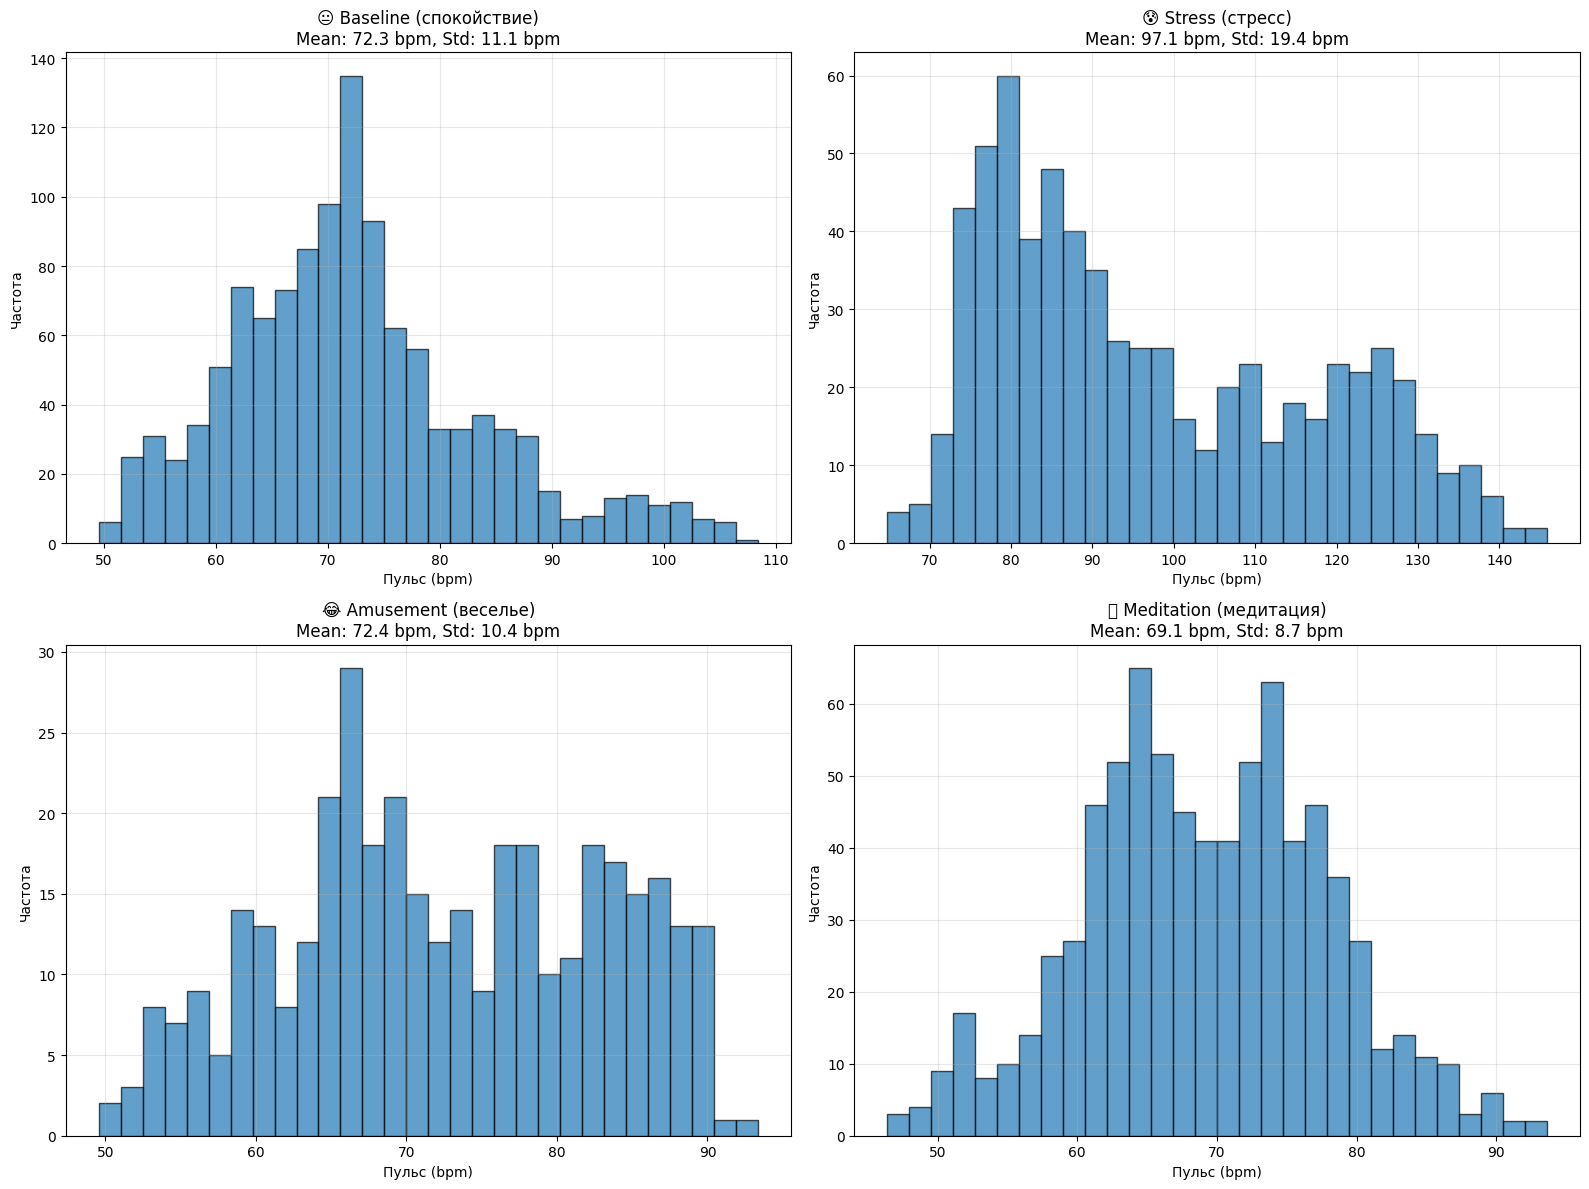

/var/folders/xv/pq9h5rt5717gr_vbvl9m8js80000gn/T/ipykernel_36041/1454314926.py:34: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xv/pq9h5rt5717gr_vbvl9m8js80000gn/T/ipykernel_36041/1454314926.py:35: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  plt.savefig('model/heart_rate_distribution_all.png', dpi=150, bbox_inches='tight')


✅ График сохранен: model/heart_rate_distribution_all.png


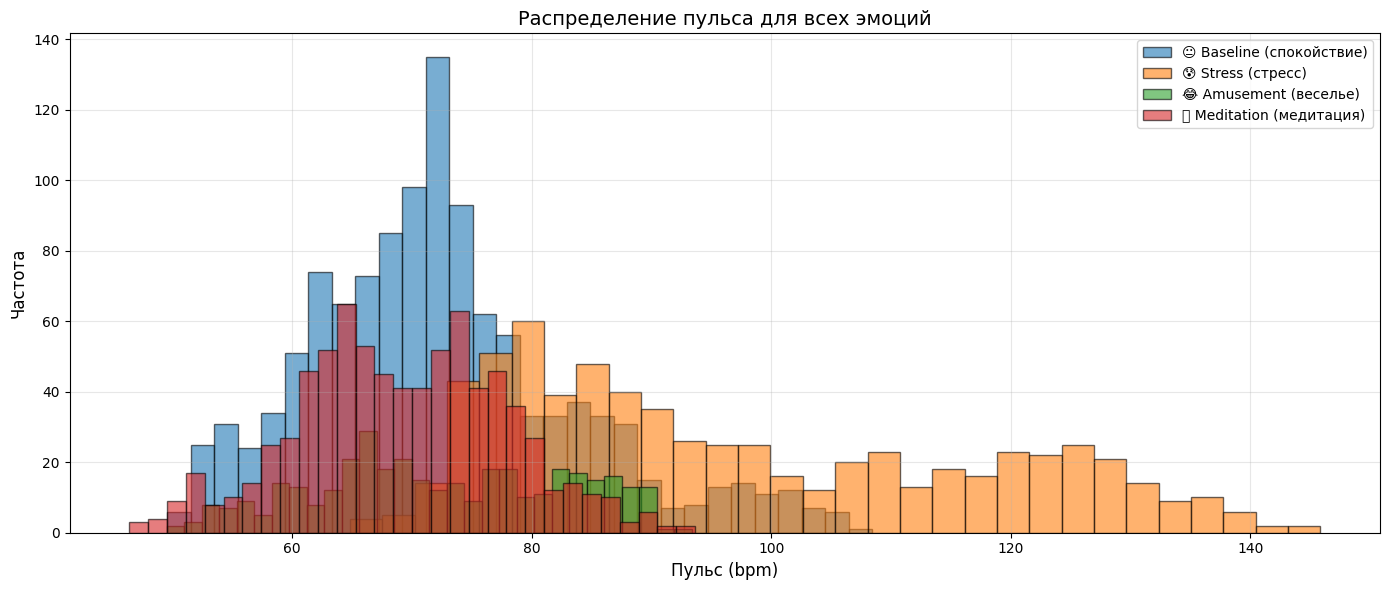

In [4]:
print("\n" + "=" * 80)
print("ВИЗУАЛИЗАЦИЯ: Распределение пульса по эмоциям")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, emotion_id in enumerate([1, 2, 3, 4]):
    mask = y_all == emotion_id
    hr_values = X_all[mask, 0]
    
    axes[idx].hist(hr_values, bins=30, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f"{EMOTION_NAMES[emotion_id]}\nMean: {hr_values.mean():.1f} bpm, Std: {hr_values.std():.1f} bpm", fontsize=12)
    axes[idx].set_xlabel('Пульс (bpm)', fontsize=10)
    axes[idx].set_ylabel('Частота', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model/heart_rate_distribution.png', dpi=150, bbox_inches='tight')
print("✅ График сохранен: model/heart_rate_distribution.png")
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
for emotion_id in [1, 2, 3, 4]:
    mask = y_all == emotion_id
    hr_values = X_all[mask, 0]
    ax.hist(hr_values, bins=30, alpha=0.6, label=EMOTION_NAMES[emotion_id], edgecolor='black')

ax.set_xlabel('Пульс (bpm)', fontsize=12)
ax.set_ylabel('Частота', fontsize=12)
ax.set_title('Распределение пульса для всех эмоций', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model/heart_rate_distribution_all.png', dpi=150, bbox_inches='tight')
print("✅ График сохранен: model/heart_rate_distribution_all.png")
plt.show()



ВИЗУАЛИЗАЦИЯ: Confusion Matrices и Accuracy


/Users/kgz/Desktop/p/metachat/.venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/var/folders/xv/pq9h5rt5717gr_vbvl9m8js80000gn/T/ipykernel_36041/2258749058.py:25: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xv/pq9h5rt5717gr_vbvl9m8js80000gn/T/ipykernel_36041/2258749058.py:26: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  plt.savefig('model/confusion_matrices.png', dpi=150, bbox_inches='tight')


✅ График сохранен: model/confusion_matrices.png


/Users/kgz/Desktop/p/metachat/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


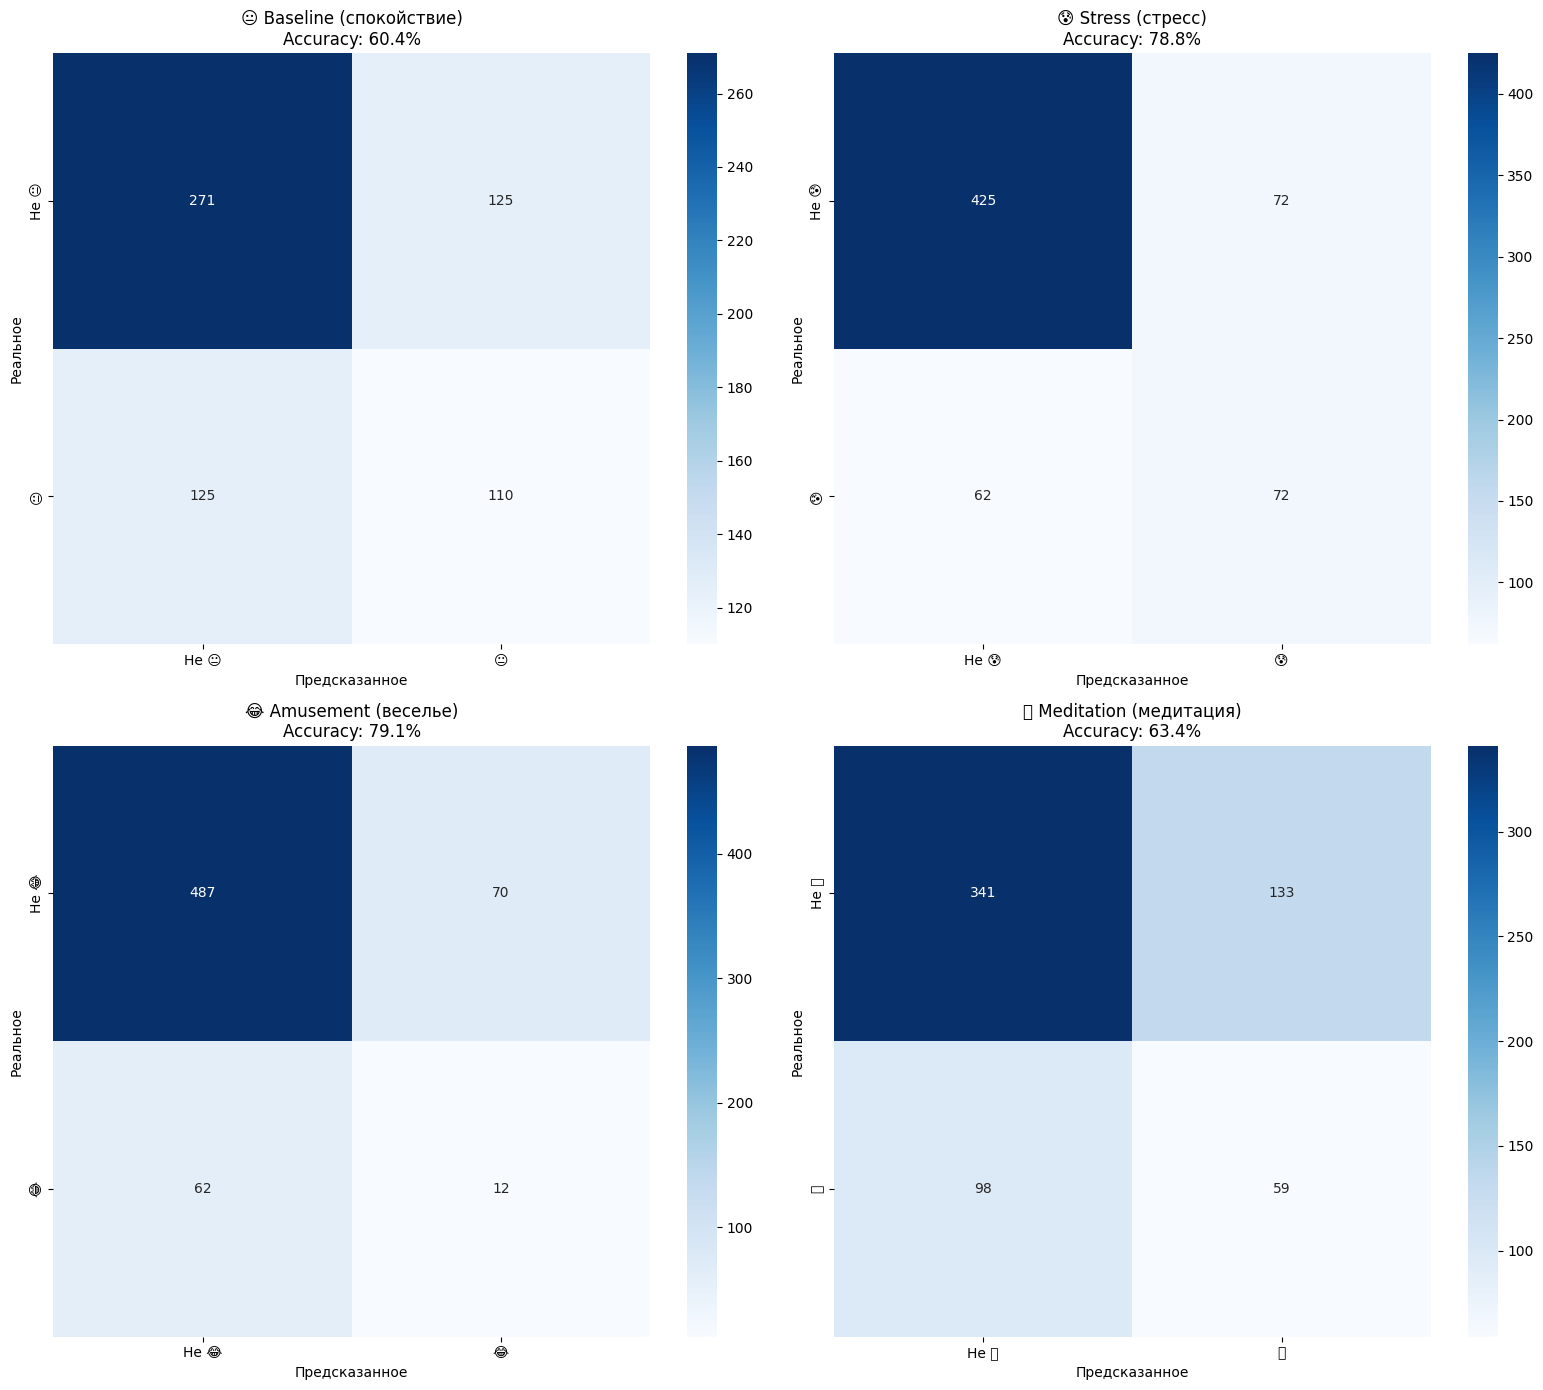

In [5]:
print("\n" + "=" * 80)
print("ВИЗУАЛИЗАЦИЯ: Confusion Matrices и Accuracy")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, emotion_id in enumerate([1, 2, 3, 4]):
    emotion_name = EMOTION_NAMES[emotion_id]
    y_binary = (y_all == emotion_id).astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_binary, test_size=0.2, random_state=42, stratify=y_binary
    )
    
    y_pred = results['predictions'][emotion_id]
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Не ' + emotion_name.split()[0], emotion_name.split()[0]],
                yticklabels=['Не ' + emotion_name.split()[0], emotion_name.split()[0]])
    axes[idx].set_title(f"{emotion_name}\nAccuracy: {results['accuracies'][emotion_id]:.1%}", fontsize=12)
    axes[idx].set_ylabel('Реальное', fontsize=10)
    axes[idx].set_xlabel('Предсказанное', fontsize=10)

plt.tight_layout()
plt.savefig('model/confusion_matrices.png', dpi=150, bbox_inches='tight')
print("✅ График сохранен: model/confusion_matrices.png")
plt.show()



ВИЗУАЛИЗАЦИЯ: Сравнение точности моделей
✅ График сохранен: model/accuracy_comparison.png


/var/folders/xv/pq9h5rt5717gr_vbvl9m8js80000gn/T/ipykernel_36041/2907218483.py:24: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xv/pq9h5rt5717gr_vbvl9m8js80000gn/T/ipykernel_36041/2907218483.py:25: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  plt.savefig('model/accuracy_comparison.png', dpi=150, bbox_inches='tight')
/Users/kgz/Desktop/p/metachat/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


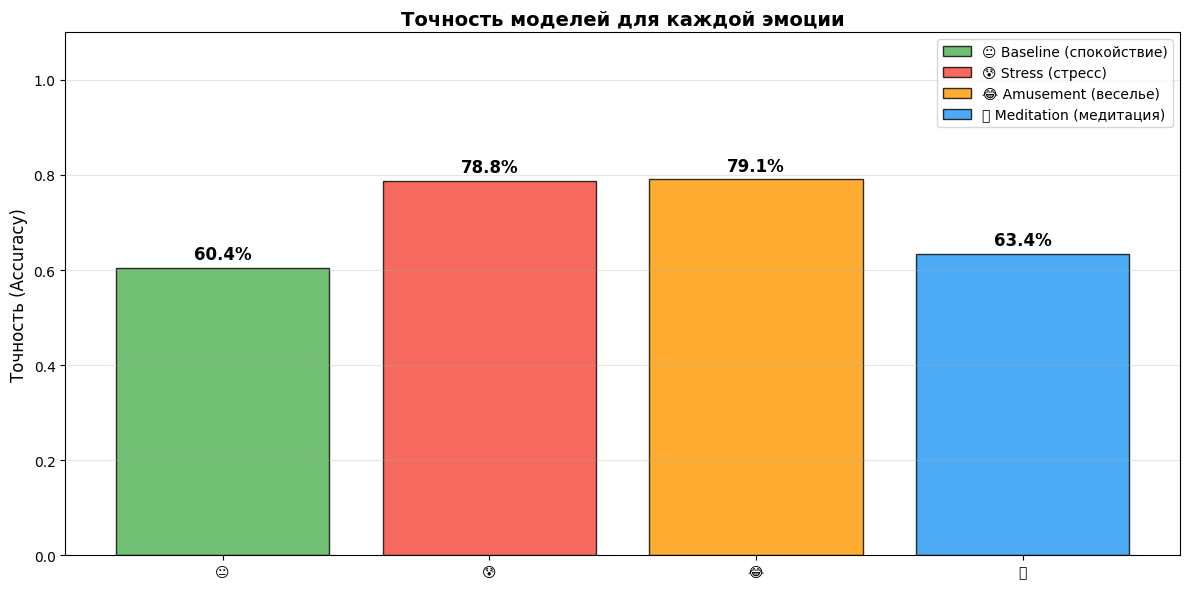

In [6]:
print("\n" + "=" * 80)
print("ВИЗУАЛИЗАЦИЯ: Сравнение точности моделей")
print("=" * 80)

emotions = [EMOTION_NAMES[i] for i in [1, 2, 3, 4]]
accuracies = [results['accuracies'][i] for i in [1, 2, 3, 4]]
colors = ['#4CAF50', '#F44336', '#FF9800', '#2196F3']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(emotions)), accuracies, color=colors, alpha=0.8, edgecolor='black')

for i, (emotion, acc) in enumerate(zip(emotions, accuracies)):
    ax.text(i, acc + 0.01, f'{acc:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    bars[i].set_label(emotion)

ax.set_ylabel('Точность (Accuracy)', fontsize=12)
ax.set_title('Точность моделей для каждой эмоции', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(emotions)))
ax.set_xticklabels([e.split()[0] for e in emotions], fontsize=10)
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('model/accuracy_comparison.png', dpi=150, bbox_inches='tight')
print("✅ График сохранен: model/accuracy_comparison.png")
plt.show()


In [7]:
print("\n" + "=" * 80)
print("ТЕСТИРОВАНИЕ НА РЕАЛЬНЫХ ДАННЫХ")
print("=" * 80 + "\n")

test_heart_rates = [
    (72.0, "Нормальный пульс в покое"),
    (95.0, "Повышенный пульс (стресс?)"),
    (110.0, "Высокий пульс (стресс/нагрузка)"),
    (65.0, "Низкий пульс (медитация?)"),
    (85.0, "Средний пульс (базовое состояние)"),
]

print("Примеры предсказаний на реальных данных:\n")

for hr, description in test_heart_rates:
    features = np.array([[hr]])
    features_scaled = scaler.transform(features)
    
    predictions = {}
    probabilities = {}
    
    for emotion_id, model in results['models'].items():
        prob = model.predict_proba(features_scaled)[0]
        predictions[emotion_id] = model.predict(features_scaled)[0]
        probabilities[emotion_id] = prob[1]
    
    predicted_emotion_id = max(probabilities.items(), key=lambda x: x[1])[0]
    confidence = probabilities[predicted_emotion_id]
    
    print(f"Пульс: {hr:.1f} bpm - {description}")
    print(f"  🎯 Предсказанная эмоция: {EMOTION_NAMES[predicted_emotion_id]}")
    print(f"  📊 Уверенность: {confidence:.1%}")
    print(f"  📈 Вероятности:")
    for emotion_id in [1, 2, 3, 4]:
        prob = probabilities[emotion_id]
        bar = '█' * int(prob * 30)
        print(f"    {EMOTION_NAMES[emotion_id]:30s} {prob:.1%} {bar}")
    print()



ТЕСТИРОВАНИЕ НА РЕАЛЬНЫХ ДАННЫХ

Примеры предсказаний на реальных данных:

Пульс: 72.0 bpm - Нормальный пульс в покое
  🎯 Предсказанная эмоция: 😂 Amusement (веселье)
  📊 Уверенность: 54.6%
  📈 Вероятности:
    😐 Baseline (спокойствие)       22.1% ██████
    😰 Stress (стресс)              0.0% 
    😂 Amusement (веселье)          54.6% ████████████████
    🧘 Meditation (медитация)       35.1% ██████████

Пульс: 95.0 bpm - Повышенный пульс (стресс?)
  🎯 Предсказанная эмоция: 😰 Stress (стресс)
  📊 Уверенность: 94.2%
  📈 Вероятности:
    😐 Baseline (спокойствие)       10.8% ███
    😰 Stress (стресс)              94.2% ████████████████████████████
    😂 Amusement (веселье)          0.0% 
    🧘 Meditation (медитация)       0.0% 

Пульс: 110.0 bpm - Высокий пульс (стресс/нагрузка)
  🎯 Предсказанная эмоция: 😰 Stress (стресс)
  📊 Уверенность: 99.5%
  📈 Вероятности:
    😐 Baseline (спокойствие)       0.0% 
    😰 Stress (стресс)              99.5% █████████████████████████████
    😂 Amusement (ве


ВИЗУАЛИЗАЦИЯ: Зависимость предсказания от пульса
✅ График сохранен: model/heart_rate_predictions.png


/var/folders/xv/pq9h5rt5717gr_vbvl9m8js80000gn/T/ipykernel_36041/1167170782.py:35: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xv/pq9h5rt5717gr_vbvl9m8js80000gn/T/ipykernel_36041/1167170782.py:36: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  plt.savefig('model/heart_rate_predictions.png', dpi=150, bbox_inches='tight')
/Users/kgz/Desktop/p/metachat/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129496 (\N{PERSON IN LOTUS POSITION}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


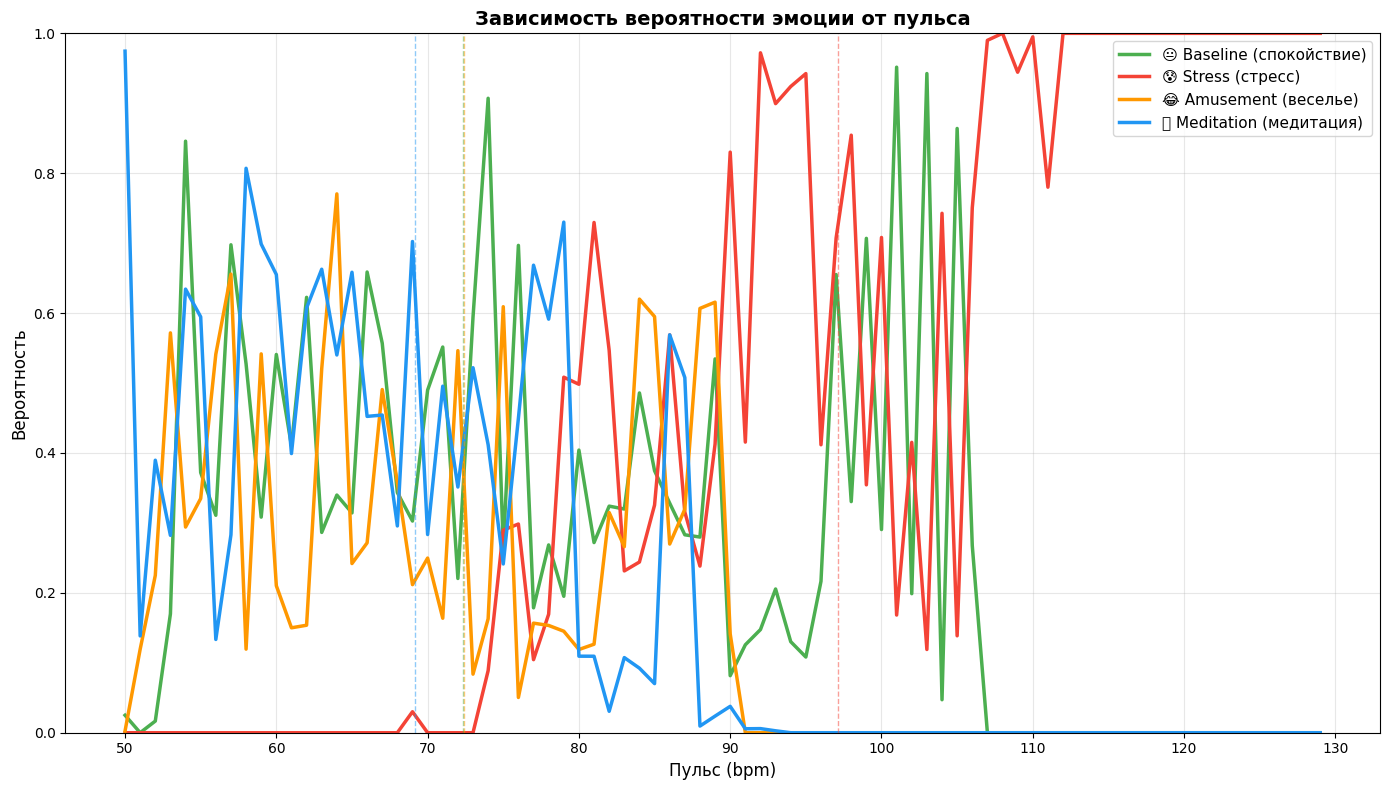

In [8]:
print("\n" + "=" * 80)
print("ВИЗУАЛИЗАЦИЯ: Зависимость предсказания от пульса")
print("=" * 80)

hr_range = np.arange(50, 130, 1)
predictions_map = {1: [], 2: [], 3: [], 4: []}

for hr in hr_range:
    features = np.array([[hr]])
    features_scaled = scaler.transform(features)
    
    for emotion_id, model in results['models'].items():
        prob = model.predict_proba(features_scaled)[0][1]
        predictions_map[emotion_id].append(prob)

fig, ax = plt.subplots(figsize=(14, 8))
colors_map = {1: '#4CAF50', 2: '#F44336', 3: '#FF9800', 4: '#2196F3'}

for emotion_id in [1, 2, 3, 4]:
    ax.plot(hr_range, predictions_map[emotion_id], 
            label=EMOTION_NAMES[emotion_id], linewidth=2.5, color=colors_map[emotion_id])

ax.set_xlabel('Пульс (bpm)', fontsize=12)
ax.set_ylabel('Вероятность', fontsize=12)
ax.set_title('Зависимость вероятности эмоции от пульса', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

for emotion_id in [1, 2, 3, 4]:
    hr_values = X_all[y_all == emotion_id, 0]
    mean_hr = hr_values.mean()
    ax.axvline(mean_hr, color=colors_map[emotion_id], linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('model/heart_rate_predictions.png', dpi=150, bbox_inches='tight')
print("✅ График сохранен: model/heart_rate_predictions.png")
plt.show()
